# Linear Regression Model, Task 2

### Importing the libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### Importing the dataset

In [ ]:
current_dir = os.path.dirname(os.getcwd())
data_dir = os.path.join(current_dir, 'data', 'processed', 'housing')
train_path = os.path.join(data_dir, 'housing_train.csv')
test_path = os.path.join(data_dir, 'housing_test.csv')

# Load data
try:
    train_data = pd.read_csv(train_path)
    test_data = pd.read_csv(test_path)
    print("Data loaded successfully")
except Exception as e:
    print(f"Error loading data: {str(e)}")
    exit()

Datos cargados correctamente


### Separate features, target, and scale

In [6]:
# separate features, target. And scale 
X_train = train_data.iloc[:, :-1].values
y_train = train_data.iloc[:, -1].values
X_test = test_data.iloc[:, :-1].values
y_test = test_data.iloc[:, -1].values

#preprocessing
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Training model

In [8]:
# 2. model with Ridge regularization
model = Ridge(alpha=10.0)   #Regularization to reduce overfitting
model.fit(X_train_scaled, y_train)

Ridge(alpha=10.0)

### Predicting the Test set results

In [9]:
# make predictions
y_pred = model.predict(X_test_scaled)

### Visualising the test set results

In [10]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMODEL RESULTS:")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


MODEL RESULTS:
MSE: 781.73
MAE: 18.92
R²: 0.74


In [11]:
# Model coefficients
coeff_df = pd.DataFrame({
'Variable': train_data.columns[:-1],
'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nMOST IMPORTANT VARIABLES:")
print(coeff_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.2f}")


MOST IMPORTANT VARIABLES:
Variable  Coefficient
   LSTAT   -25.127288
     DIS   -16.223907
      RM    14.516747
 PTRATIO   -12.772485
     NOX   -12.181599
     RAD    11.451490
     TAX    -9.803158
       B     7.916829
    CRIM    -6.715785
     AGE    -4.475186
    CHAS     3.324275
      ZN     2.663188
   INDUS    -0.066162

Intercept: 112.40


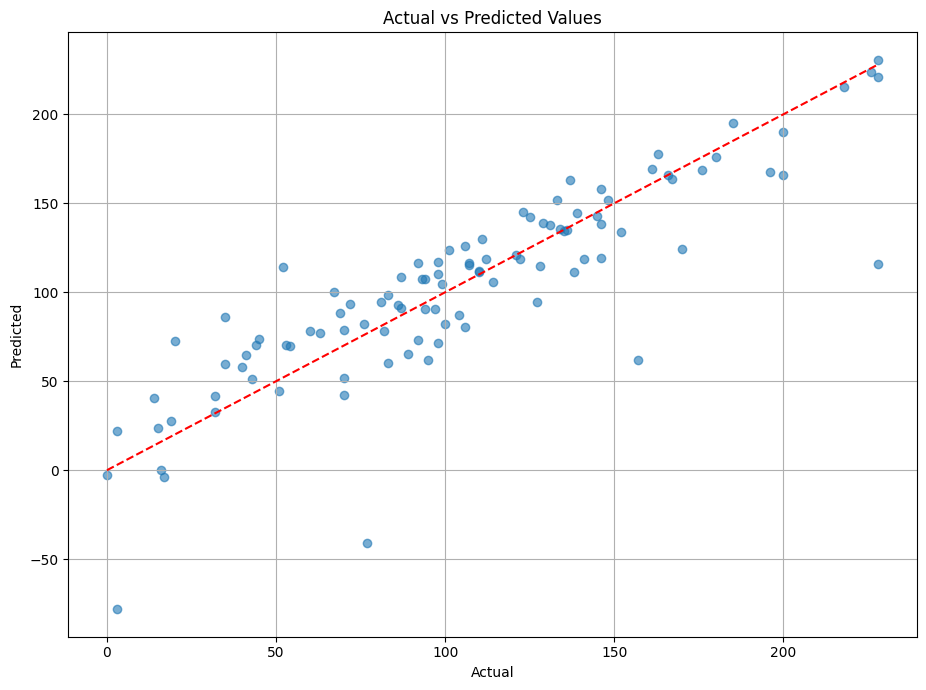

In [12]:
#VISUALIZATIONS
plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.title('Actual vs Predicted Values')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)

plt.tight_layout()
plt.show()